In [1]:
import os

def extract_measured_values(file_path, save_over_original=True):
    with open(file_path, 'r', encoding='latin1') as f:
        lines = f.readlines()

    # Find the index where "Measured values" appears
    start_index = None
    for i, line in enumerate(lines):
        if line.strip().startswith("Measured values"):
            start_index = i
            break

    if start_index is None:
        print(f"'Measured values' not found in {file_path}")
        return

    # Keep only from "Measured values" onward
    extracted_lines = lines[start_index:]

    # Save to the same file or a new one
    output_path = file_path if save_over_original else file_path.replace(".txt", "_extracted.txt")
    with open(output_path, 'w', encoding='utf-8') as f:
        f.writelines(extracted_lines)

    print(f"Processed: {file_path}")

# Path to your folder of .txt files
folder_path = "C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2"

# Process all .txt files in the folder
for filename in os.listdir(folder_path):
    if filename.lower().endswith(".txt"):
        full_path = os.path.join(folder_path, filename)
        extract_measured_values(full_path)

Processed: C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2\Prove Nuove BBI-68 VIDIT## 01.TXT
Processed: C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2\Prove Nuove BBI-68 VIDIT## 02.TXT
Processed: C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2\Prove Nuove BBI-68 VIDIT## 03.TXT
Processed: C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2\Prove Nuove BBI-68 VIDIT## 04.TXT
Processed: C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2\Prove Nuove BBI-68 VIDIT## 05.TXT
Processed: C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2\Prove Nuove BBI-68 VIDIT## 06.TXT
Processed: C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2\Prove Nuove BBI-68 VIDIT## 07.TXT
Processed: C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2\Prove Nuove BBI-68 VIDIT## 08.TXT
Processed: C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2\Prove Nuove BBI-68 VIDIT## 09.TXT
Processed: C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2\Prove Nuove BBI-68 VIDIT

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from scipy.fft import fft, fftfreq
import glob
import os
from pathlib import Path
import re

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class TimeSeriesSetAnalyzer:
    def __init__(self, folder_path, output_path):
        self.folder_path = Path(folder_path)
        self.output_path = Path(output_path)
        self.output_path.mkdir(parents=True, exist_ok=True)
        self.data_files = []
        self.datasets = {}  # Individual files
        self.sets = {}      # Grouped by sets
        self.set_stats = {} # Statistics per set
        
    def load_data(self, file_pattern="*.TXT"):
        """Load all TXT files and group them into sets"""
        # Handle both .txt and .TXT extensions
        search_patterns = [
            self.folder_path / file_pattern,
            self.folder_path / file_pattern.replace('.TXT', '.txt')
        ]
        
        self.data_files = []
        for pattern in search_patterns:
            self.data_files.extend(glob.glob(str(pattern)))
        
        # Remove duplicates
        self.data_files = list(set(self.data_files))
        print(f"Found {len(self.data_files)} files in {self.folder_path}")
        
        # Load individual files
        for file_path in self.data_files:
            try:
                # Try different separators
                df = pd.read_csv(file_path, sep='\t', skiprows=1)
                if df.shape[1] == 1:
                    df = pd.read_csv(file_path, sep=r'\s+', skiprows=1)
                
                file_name = Path(file_path).name  # Keep full filename with extension
                self.datasets[file_name] = df
                
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
        
        # Group files into sets
        self._group_into_sets()
        print(f"Loaded {len(self.datasets)} files grouped into {len(self.sets)} sets")
        
    def _group_into_sets(self):
        """Automatically group files into sets based on filename patterns"""
        # Specific pattern for your files: "Prove BBI-68 VIDIT#Set1# 01.TXT"
        set_pattern = r'#Set(\d+)#'
        
        print("\nFile grouping:")
        print("Sample files:", list(self.datasets.keys())[:3], "..." if len(self.datasets) > 3 else "")
        
        # Apply the specific pattern for your naming convention
        groups = {}
        for filename in self.datasets.keys():
            match = re.search(set_pattern, filename, re.IGNORECASE)
            if match:
                set_number = match.group(1)
                set_name = f"Set_{set_number}"
                if set_name not in groups:
                    groups[set_name] = []
                groups[set_name].append(filename)
            else:
                # Fallback for files that don't match the pattern
                if "Other" not in groups:
                    groups["Other"] = []
                groups["Other"].append(filename)
        
        self.sets = groups
        
        # Display grouping results
        for set_name, files in self.sets.items():
            print(f"Set '{set_name}': {len(files)} files")
            if len(files) <= 3:  # Show filenames for small groups
                for f in files:
                    print(f"  - {f}")
        
        # Validate that we have the expected structure
        if len(self.sets) == 3 and all(len(files) == 16 for files in self.sets.values()):
            print("✓ Perfect! Found 3 sets with 16 files each as expected.")
        elif "Other" in self.sets:
            print("⚠ Warning: Some files don't match the expected pattern and were grouped as 'Other'")
            
    def get_file_info(self, filename):
        """Extract information from filename"""
        # Pattern for: "Prove BBI-68 VIDIT#Set1# 01.TXT"
        pattern = r'.*#Set(\d+)#\s*(\d+)\.TXT'
        match = re.search(pattern, filename, re.IGNORECASE)
        
        if match:
            set_number = int(match.group(1))
            file_number = int(match.group(2))
            return {
                'set': set_number,
                'file_number': file_number,
                'set_name': f'Set_{set_number}'
            }
        return None
    
    def manual_grouping(self, set_definitions):
        """Manually define sets
        set_definitions: dict like {'Set_A': ['file1', 'file2'], 'Set_B': ['file3', 'file4']}
        """
        self.sets = set_definitions
        print("Manual grouping applied:")
        for set_name, files in self.sets.items():
            print(f"{set_name}: {len(files)} files")
    
    def calculate_set_statistics(self):
        """Calculate statistics for each set"""
        for set_name, file_list in self.sets.items():
            set_data = []
            
            for filename in file_list:
                if filename in self.datasets:
                    df = self.datasets[filename].copy()
                    df['filename'] = filename
                    set_data.append(df)
            
            if set_data:
                combined_df = pd.concat(set_data, ignore_index=True)
                
                # Calculate statistics
                numeric_cols = ['Pd (nm)', 'Fn (mN)']
                stats_dict = {}
                
                for col in numeric_cols:
                    if col in combined_df.columns:
                        stats_dict[col] = {
                            'mean': combined_df[col].mean(),
                            'std': combined_df[col].std(),
                            'median': combined_df[col].median(),
                            'min': combined_df[col].min(),
                            'max': combined_df[col].max(),
                            'q25': combined_df[col].quantile(0.25),
                            'q75': combined_df[col].quantile(0.75)
                        }
                
                self.set_stats[set_name] = {
                    'data': combined_df,
                    'stats': stats_dict,
                    'n_files': len(file_list)
                }

    def export_summary_report(self, filename="summary_report.txt"):
        """Scrive il report testuale in output_path/filename"""
        if not self.set_stats:
            self.calculate_set_statistics()
    
        out_file = self.output_path / filename
        with open(out_file, 'w', encoding='utf-8') as f:
            f.write("="*60 + "\n")
            f.write("COMPREHENSIVE SET ANALYSIS REPORT\n")
            f.write("="*60 + "\n\n")
            f.write(f"Total files analyzed: {len(self.datasets)}\n")
            f.write(f"Number of sets: {len(self.sets)}\n\n")
            for set_name, set_info in self.set_stats.items():
                f.write("-"*40 + "\n")
                f.write(f"SET: {set_name}\n")
                f.write("-"*40 + "\n")
                f.write(f"Number of files: {set_info['n_files']}\n")
                for var, stats in set_info['stats'].items():
                    f.write(f"\n{var}:\n")
                    f.write(f"  Mean:   {stats['mean']:.4f} ± {stats['std']:.4f}\n")
                    f.write(f"  Std:    {stats['std']:.4f}\n")
                    f.write(f"  Median: {stats['median']:.4f}\n")
                    f.write(f"  Min–Max: [{stats['min']:.4f}, {stats['max']:.4f}]\n")
                    f.write(f"  IQR:    [{stats['q25']:.4f}, {stats['q75']:.4f}]\n")
                f.write("\n")
        print(f"Summary report written to {out_file}")

    
    def plot_set_comparison_ordered(self, figsize=(16, 6)):
        """Compare sets with files ordered by number—two panels only."""
        if not self.set_stats:
            self.calculate_set_statistics()
        
        variables = ['Pd (nm)', 'Fn (mN)']
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        colors = plt.cm.Set1(np.linspace(0, 1, len(self.sets)))
        
        for i, var in enumerate(variables):
            ax = axes[i]
            for j, (set_name, file_list) in enumerate(self.sets.items()):
                sorted_files = sorted(
                    file_list,
                    key=lambda fn: self.get_file_info(fn)['file_number'] or 0
                )
                traces = []
                for fn in sorted_files:
                    df = self.datasets.get(fn)
                    if df is not None and var in df.columns:
                        ax.plot(df['Time (s)'], df[var],
                                color=colors[j], alpha=0.15, linewidth=0.5)
                        traces.append(df[['Time (s)', var]])
                if traces:
                    combined = pd.concat(traces, ignore_index=True)
                    mean_curve = combined.groupby('Time (s)')[var].mean()
                    ax.plot(mean_curve.index, mean_curve.values,
                            color=colors[j], linewidth=3,
                            label=f'{set_name} mean (n={len(sorted_files)})')
            ax.set_xlabel('Time (s)')
            ax.set_ylabel(var)
            ax.set_title(f'{var} – Set Comparison')
            ax.legend()
            ax.grid(alpha=0.3)
        
        plt.suptitle('BBI-68 VIDIT Set Comparison', fontsize=16)
        plt.tight_layout()
        out_file = self.output_path / "set_comparison_ordered.png"
        fig.savefig(out_file, dpi=300)
        print(f"Saved figure to {out_file}")
        plt.show()
    
    def plot_set_statistics_summary(self, figsize=(15, 10)):
        """Plot statistical summary comparison between sets"""
        if not self.set_stats:
            self.calculate_set_statistics()
        
        variables = ['Pd (nm)', 'Fn (mN)']
        metrics = ['mean', 'std', 'median', 'max']
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        axes = axes.flatten()
        
        for i, metric in enumerate(metrics):
            ax = axes[i]
            
            # Prepare data for grouped bar chart
            set_names = list(self.set_stats.keys())
            x = np.arange(len(variables))
            width = 0.8 / len(set_names)
            
            for j, set_name in enumerate(set_names):
                values = []
                for var in variables:
                    if var in self.set_stats[set_name]['stats']:
                        values.append(self.set_stats[set_name]['stats'][var][metric])
                    else:
                        values.append(0)
                
                ax.bar(x + j * width, values, width, label=set_name, alpha=0.8)
            
            ax.set_xlabel('Variables')
            ax.set_ylabel(f'{metric.capitalize()}')
            ax.set_title(f'{metric.capitalize()} Comparison Across Sets')
            ax.set_xticks(x + width * (len(set_names) - 1) / 2)
            ax.set_xticklabels(variables, rotation=45)
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.suptitle('Statistical Summary - Set Comparison', fontsize=16)
        plt.tight_layout()
        out_file = self.output_path / "set_statistics_summary.png"
        fig.savefig(out_file, dpi=300)
        print(f"Saved figure to {out_file}")
        plt.show()
    
    def plot_set_boxplots(self, figsize=(16, 8)):
        """Box plots comparing distributions across sets"""
        if not self.set_stats:
            self.calculate_set_statistics()
        
        variables = ['Pd (nm)', 'Fn (mN)']
        fig, axes = plt.subplots(1, len(variables), figsize=figsize)
        
        for i, var in enumerate(variables):
            data_for_boxplot = []
            labels = []
            
            for set_name, set_info in self.set_stats.items():
                if var in set_info['data'].columns:
                    data_for_boxplot.append(set_info['data'][var].dropna())
                    labels.append(set_name)
            
            if data_for_boxplot:
                axes[i].boxplot(data_for_boxplot, tick_labels=labels)
                axes[i].set_title(f'{var} Distribution')
                axes[i].tick_params(axis='x', rotation=45)
                axes[i].grid(True, alpha=0.3)
        
        plt.suptitle('Distribution Comparison Across Sets', fontsize=16)
        plt.tight_layout()
        out_file = self.output_path / "set_boxplots.png"
        fig.savefig(out_file, dpi=300)
        print(f"Saved figure to {out_file}")
        plt.show()
    
    def plot_segment_comparison(self, figsize=(8, 6)):
        """Compare average segment durations across sets."""
        if not self.set_stats:
            self.calculate_set_statistics()
        
        # Only one plot now
        fig, ax = plt.subplots(figsize=figsize)
        colors = plt.cm.Set1(np.linspace(0, 1, len(self.sets)))
        
        # Build bars for each set
        for i, (set_name, set_info) in enumerate(self.set_stats.items()):
            data = set_info['data']
            if 'SegmentID' in data.columns:
                # Compute duration per file‐segment
                seg_durations = (
                    data
                    .groupby(['filename', 'SegmentID'])['Time (s)']
                    .agg(['min', 'max'])
                )
                seg_durations['duration'] = seg_durations['max'] - seg_durations['min']
                
                # Average duration by segment
                avg_durations = seg_durations.groupby('SegmentID')['duration'].mean()
                
                # Offset bars horizontally
                ax.bar(
                    avg_durations.index + i*0.2,
                    avg_durations.values,
                    width=0.2,
                    label=set_name,
                    color=colors[i],
                    alpha=0.8
                )
        
        ax.set_xlabel('Segment ID')
        ax.set_ylabel('Average Duration (s)')
        ax.set_title('Average Segment Duration by Set')
        ax.legend()
        ax.grid(alpha=0.3)
        
        plt.tight_layout()
        out_file = self.output_path / "segment_comparison.png"
        fig.savefig(out_file, dpi=300)
        print(f"Saved figure to {out_file}")
        plt.show()

      
    def generate_summary_report(self):
        """Generate a comprehensive summary report"""
        if not self.set_stats:
            self.calculate_set_statistics()
        
        print("="*60)
        print("COMPREHENSIVE SET ANALYSIS REPORT")
        print("="*60)
        
        print(f"\nTotal files analyzed: {len(self.datasets)}")
        print(f"Number of sets: {len(self.sets)}")
        
        for set_name, set_info in self.set_stats.items():
            print(f"\n{'-'*40}")
            print(f"SET: {set_name}")
            print(f"{'-'*40}")
            print(f"Number of files: {set_info['n_files']}")
            
            for var, stats in set_info['stats'].items():
                print(f"\n{var}:")
                print(f"  Mean: {stats['mean']:.4f} ± {stats['std']:.4f}")
                print(f"  Median: {stats['median']:.4f}")
                print(f"  Range: [{stats['min']:.4f}, {stats['max']:.4f}]")
                print(f"  IQR: [{stats['q25']:.4f}, {stats['q75']:.4f}]")
    
    def comprehensive_set_analysis(self):
        """Run all set-based analyses"""
        if not self.datasets:
            print("No data loaded. Please run load_data() first.")
            return
        
        print("=== CALCULATING SET STATISTICS ===")
        self.calculate_set_statistics()
        
        print("\n=== GENERATING SUMMARY REPORT ===")
        self.generate_summary_report()
        self.export_summary_report()
        
        print("\n=== GENERATING PLOTS ===")
        self.plot_set_comparison_ordered()
        self.plot_set_statistics_summary()
        self.plot_set_boxplots()
        self.plot_segment_comparison()


Found 48 files in C:\Users\geard\OneDrive\Download\Tesi\dati_ts\dataset_2

File grouping:
Sample files: ['Prove Nuove BBI-68 VIDIT#Set2# 11.TXT', 'Prove Nuove BBI-68 VIDIT#Set3# 08.TXT', 'Prove Nuove BBI-68 VIDIT#Set2# 08.TXT'] ...
Set 'Set_2': 16 files
Set 'Set_3': 16 files
Set 'Set_1': 16 files
✓ Perfect! Found 3 sets with 16 files each as expected.
Loaded 48 files grouped into 3 sets
=== CALCULATING SET STATISTICS ===

=== GENERATING SUMMARY REPORT ===
COMPREHENSIVE SET ANALYSIS REPORT

Total files analyzed: 48
Number of sets: 3

----------------------------------------
SET: Set_2
----------------------------------------
Number of files: 16

Pd (nm):
  Mean: 177.8006 ± 51.3600
  Median: 157.4022
  Range: [0.0000, 291.3384]
  IQR: [156.4961, 176.0482]

Fn (mN):
  Mean: 2.7098 ± 3.1474
  Median: 0.9999
  Range: [-0.0012, 10.0168]
  IQR: [0.9970, 2.9324]

----------------------------------------
SET: Set_3
----------------------------------------
Number of files: 16

Pd (nm):
  Mean: 1

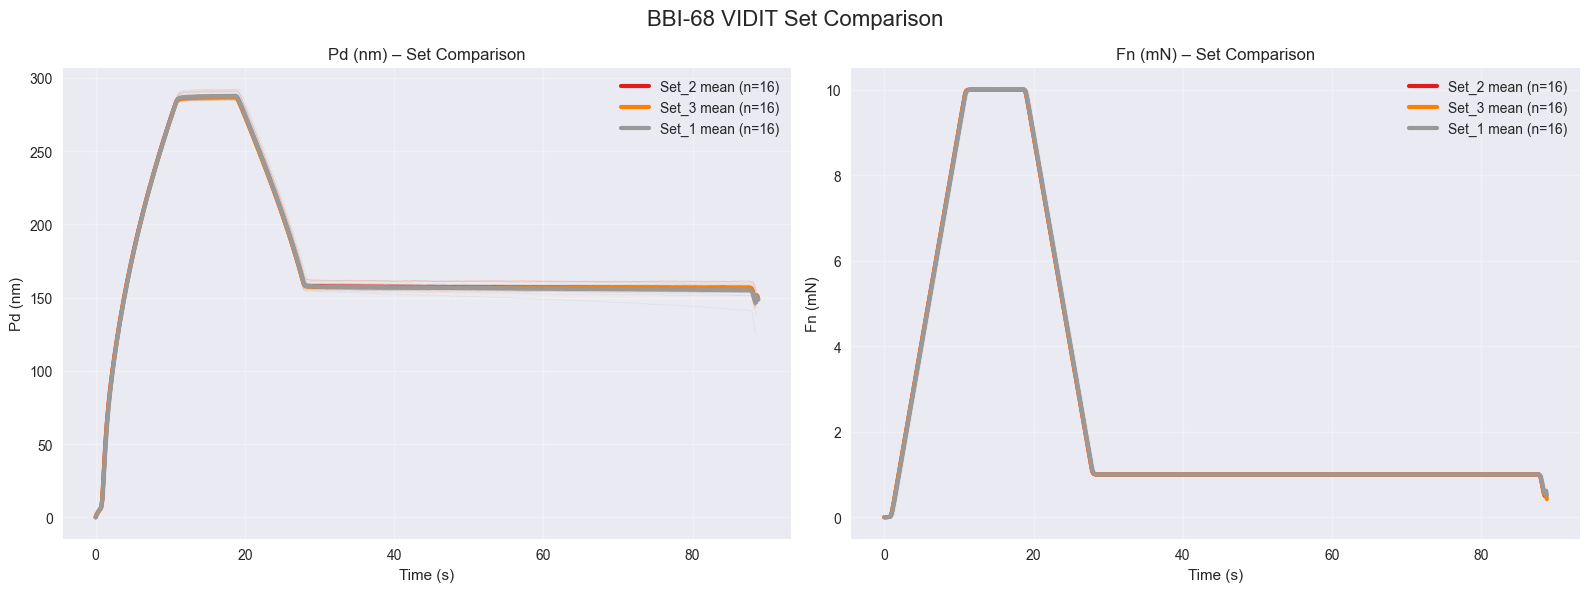

Saved figure to C:\Users\geard\OneDrive\Download\Tesi\images_ts\dataset_2\set_statistics_summary.png


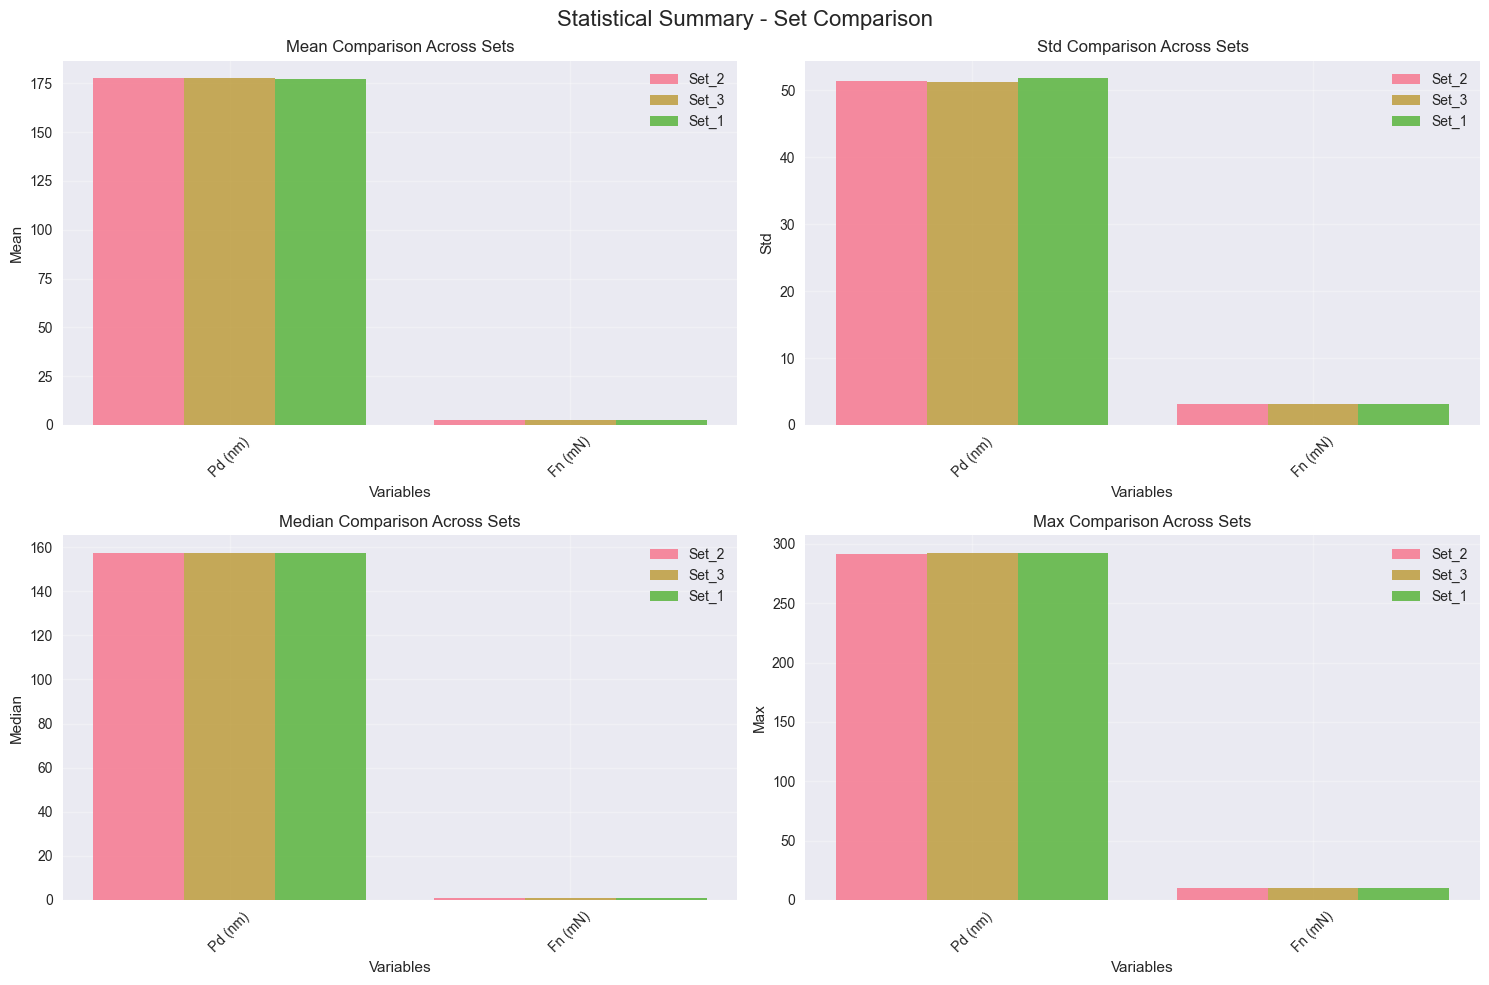

Saved figure to C:\Users\geard\OneDrive\Download\Tesi\images_ts\dataset_2\set_boxplots.png


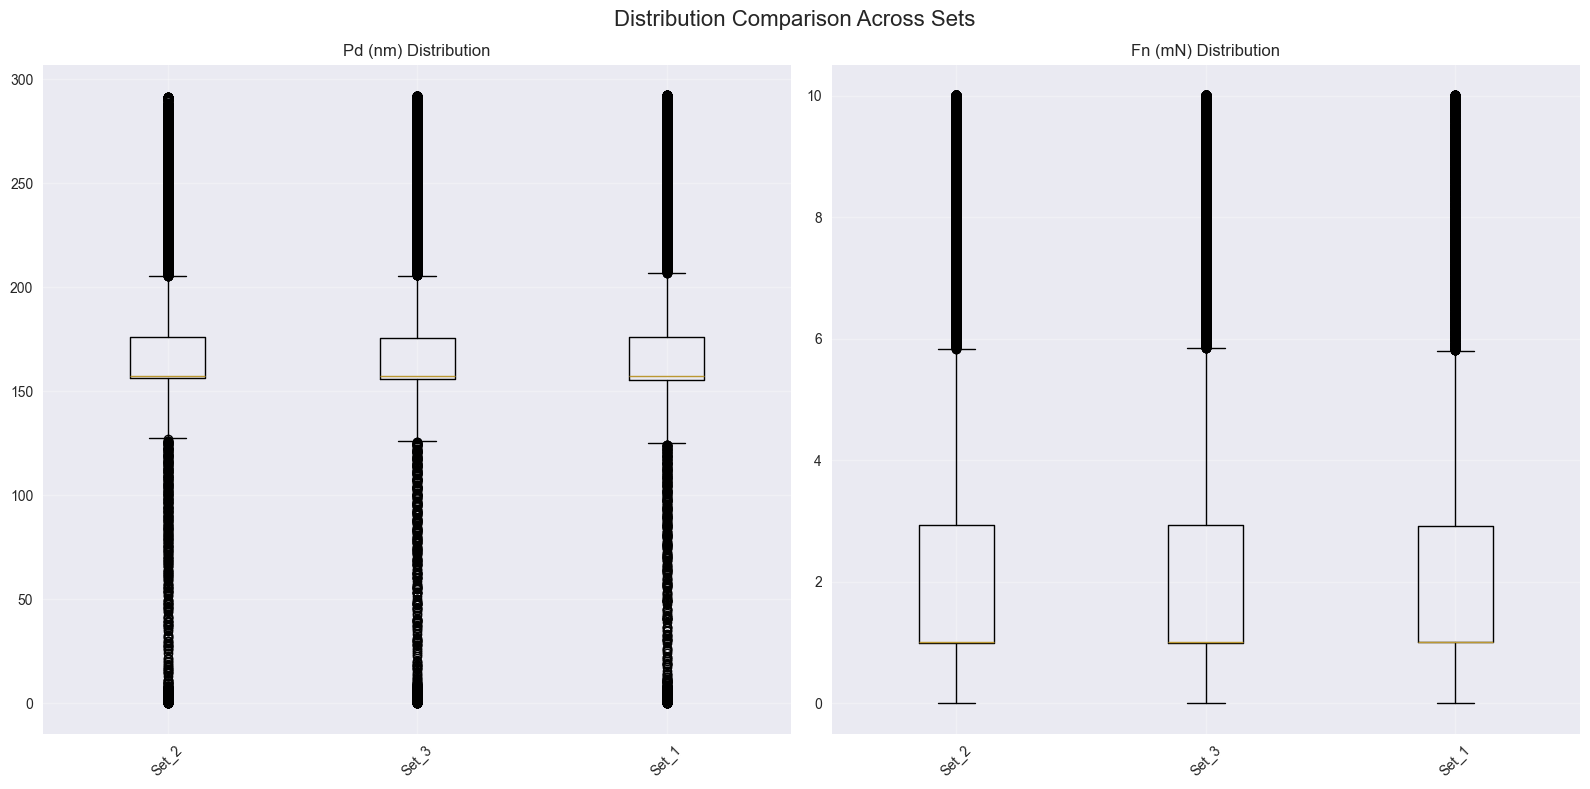

Saved figure to C:\Users\geard\OneDrive\Download\Tesi\images_ts\dataset_2\segment_comparison.png


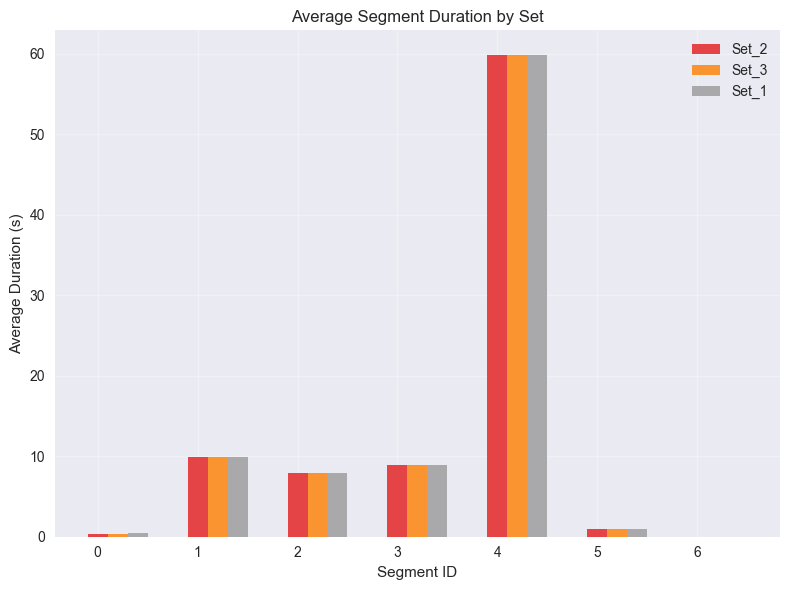

In [5]:
folder_path = "C:/Users/geard/OneDrive/Download/Tesi/dati_ts/dataset_2"  # Change this to your folder path
output_path = "C:/Users/geard/OneDrive/Download/Tesi/images_ts/dataset_2"
analyzer = TimeSeriesSetAnalyzer(folder_path, output_path)

# Load data (now handles .TXT extension)
analyzer.load_data("*.TXT")  # Will automatically detect your files

# Run comprehensive analysis
analyzer.comprehensive_set_analysis()

# Individual analyses are also available:
#analyzer.generate_summary_report()
#analyzer.export_summary_report()
#analyzer.plot_set_comparison_ordered()  # Optimized for your file naming
#analyzer.plot_set_statistics_summary()
#analyzer.plot_set_boxplots()
#analyzer.plot_segment_comparison()